In [10]:
from graph.higher_dim_graph import Graph
from graph.graph import restore_from_csv
import metrics.metrics as mtx
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import powerlaw
import os
import re
import prepare
from run_maltparser import annotate
from make_graph_en import build_en_graph
from make_graph_ru import build_ru_graph
from eng_rb_anaphora import resolve_anaphora_en
from ru_rb_anaphora import resolve_anaphora_ru
import nltk
from nltk.tokenize import sent_tokenize
import string
from tqdm import tqdm

# Download required NLTK data if not present
# nltk.download("punkt_tab")


# Prepare corpus

In [11]:
def get_all_txt_files(directory):
    """
    Get all .txt files from a directory and its subdirectories.
    
    Args:
        directory (str): The root directory to search in.
    
    Returns:
        list: A list of strings, each being the content of a .txt file.
    """
    txt_contents = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.txt'):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                        txt_contents.append(content)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return txt_contents

In [12]:
def clean_angle_brackets(text):
    """
    Remove text enclosed in angle brackets <> from a string.
    
    Args:
        text (str): The input string.
    
    Returns:
        str: The cleaned string with angle bracket content removed.
    """
    return re.sub(r'<[^>]*>', '', text)

In [13]:
print(' Eng standard')
sum = 0
texsts_es = sorted(get_all_txt_files('corpus/eng_standard'), key=lambda x: len(x.split()))[:1000]
texsts_es = [' '.join(clean_angle_brackets(text).split()[:400]) for text in texsts_es]  # Truncate to first 400 words
for text in texsts_es:
    sum += len(text.split())
print(f"Number of files: {len(texsts_es)}")
print(f"Mean words in Eng standard: {sum / len(texsts_es) if texsts_es else 0}")

print('\n Ru standard')
sum = 0
texsts_rs = sorted(get_all_txt_files('corpus/ru_standard'), key=lambda x: len(x.split()))[:1000]
texsts_rs = [' '.join(clean_angle_brackets(text).split()[:700]) for text in texsts_rs]  # Truncate to first 500 words
for text in texsts_rs:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rs)}")
print(f"Mean words in Ru standard: {sum / len(texsts_rs) if texsts_rs else 0}")

print('\n Eng learner')
sum = 0
texsts_el = sorted(get_all_txt_files('corpus/eng_non_standard'), key=lambda x: len(x.split()))[23000:24000]
texsts_el = [' '.join(clean_angle_brackets(text).split()[:400]) for text in texsts_el]  # Truncate to first 400 words
for text in texsts_el:
    sum += len(text.split())
print(f"Number of files: {len(texsts_el)}")
print(f"Mean words in Eng learner: {sum / len(texsts_el) if texsts_el else 0}")

print('\n Ru learner')
sum = 0
texsts_rl = sorted(get_all_txt_files('corpus/ru_non_standard'), key=lambda x: len(x.split()))[1896:]
texsts_rl = [clean_angle_brackets(text) for text in texsts_rl]  # Clean the texts
for text in texsts_rl:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rl)}")
print(f"Mean words in Ru learner: {sum / len(texsts_rl) if texsts_rl else 0}")

 Eng standard
Number of files: 1000
Mean words in Eng standard: 399.427

 Ru standard
Number of files: 1000
Mean words in Ru standard: 385.431

 Eng learner
Number of files: 1000
Mean words in Eng learner: 394.187

 Ru learner
Number of files: 1000
Mean words in Ru learner: 385.806


In [25]:
print(' Eng standard')
sum = 0
texsts_es = sorted(get_all_txt_files('corpus/eng_standard'), key=lambda x: len(x.split()))[:100]
texsts_es = [' '.join(clean_angle_brackets(text).split()) for text in texsts_es]  # Truncate to first 400 words
for text in texsts_es:
    sum += len(text.split())
print(f"Number of files: {len(texsts_es)}")
print(f"Mean words in Eng standard: {sum / len(texsts_es) if texsts_es else 0}")

print('\n Ru standard')
sum = 0
texsts_rs = sorted(get_all_txt_files('corpus/ru_standard'), key=lambda x: len(x.split()))[650:750]
texsts_rs = [' '.join(clean_angle_brackets(text).split()) for text in texsts_rs]  # Truncate to first 500 words
for text in texsts_rs:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rs)}")
print(f"Mean words in Ru standard: {sum / len(texsts_rs) if texsts_rs else 0}")

print('\n Eng learner')
sum = 0
texsts_el = sorted(get_all_txt_files('corpus/eng_non_standard'), key=lambda x: len(x.split()))[24000:24100]
texsts_el = [' '.join(clean_angle_brackets(text).split()) for text in texsts_el]  # Truncate to first 400 words
for text in texsts_el:
    sum += len(text.split())
print(f"Number of files: {len(texsts_el)}")
print(f"Mean words in Eng learner: {sum / len(texsts_el) if texsts_el else 0}")

print('\n Ru learner')
sum = 0
texsts_rl = sorted(get_all_txt_files('corpus/ru_non_standard'), key=lambda x: len(x.split()))[2700:2800]
texsts_rl = [clean_angle_brackets(text) for text in texsts_rl]  # Clean the texts
for text in texsts_rl:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rl)}")
print(f"Mean words in Ru learner: {sum / len(texsts_rl) if texsts_rl else 0}")

 Eng standard
Number of files: 100
Mean words in Eng standard: 539.96

 Ru standard
Number of files: 100
Mean words in Ru standard: 527.49

 Eng learner
Number of files: 100
Mean words in Eng learner: 500.36

 Ru learner
Number of files: 100
Mean words in Ru learner: 531.08


In [26]:
def create_corpus_df(texts):
    """
    Create a DataFrame from a list of texts with columns 'text' and 'word_count'.
    
    Args:
        texts (list): List of strings, each being a text.
    
    Returns:
        pd.DataFrame: DataFrame with 'text' and 'word_count' columns.
    """
    word_counts = [len(text.split()) for text in texts]
    df = pd.DataFrame({'text': texts, 'word_count': word_counts})
    return df

# Create DataFrames for each balanced corpus
eng_standard_df = create_corpus_df(texsts_es)
eng_non_standard_df = create_corpus_df(texsts_el)
ru_standard_df = create_corpus_df(texsts_rs)
ru_non_standard_df = create_corpus_df(texsts_rl)

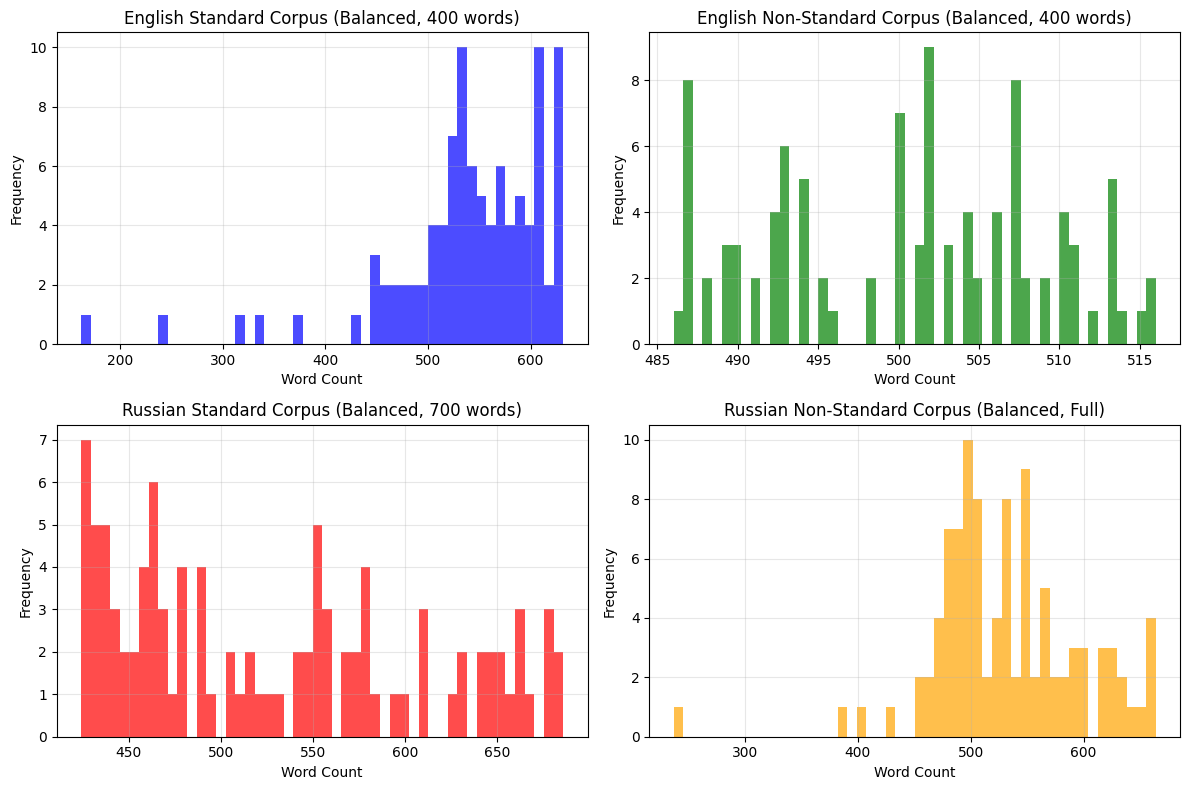

In [27]:
# Compute word counts for the balanced corpora
es_word_counts = [len(text.split()) for text in texsts_es]
el_word_counts = [len(text.split()) for text in texsts_el]
rs_word_counts = [len(text.split()) for text in texsts_rs]
rl_word_counts = [len(text.split()) for text in texsts_rl]

# For raw corpora
# es_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/eng_standard')]
# el_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/eng_non_standard')]
# rs_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/ru_standard')]
# rl_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/ru_non_standard')]

# Create 4 subplots for word count distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# English Standard
axes[0, 0].hist(es_word_counts, bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title('English Standard Corpus (Balanced, 400 words)')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# English Non-Standard (Learner)
axes[0, 1].hist(el_word_counts, bins=50, alpha=0.7, color='green')
axes[0, 1].set_title('English Non-Standard Corpus (Balanced, 400 words)')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Russian Standard
axes[1, 0].hist(rs_word_counts, bins=50, alpha=0.7, color='red')
axes[1, 0].set_title('Russian Standard Corpus (Balanced, 700 words)')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Russian Non-Standard (Learner)
axes[1, 1].hist(rl_word_counts, bins=50, alpha=0.7, color='orange')
axes[1, 1].set_title('Russian Non-Standard Corpus (Balanced, Full)')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate metrics

In [28]:
def process_text_to_graph(text, lang):
    """
    Process a text to build a graph using the pipeline.
    
    Args:
        text (str): The input text.
        lang (str): Language ('en' or 'ru').
    
    Returns:
        Graph: The built graph object.
    """
    sentences = sent_tokenize(text)
    cleaned_sentences = []
    for s in sentences:
        s = s.strip().replace("\n", " ").replace("\t", " ").lower()
        cleaned_sentences.append("".join(ch for ch in s if ch not in (string.punctuation)))
    sentences = cleaned_sentences
    input_path = "input.conll"

    with open(input_path, "w") as f:
        for sent in sentences:
            f.write(f"# text = {sent}\n")
            conll_data = prepare.sentence_to_conllx(sent, lang=lang)
            f.write(conll_data)
            f.write("\n")

    annotate("input.conll", "output.conll", lang=lang)

    if lang == 'en':
        resolved_sentences = resolve_anaphora_en("output.conll")
    elif lang == 'ru':
        resolved_sentences = resolve_anaphora_ru("output.conll")

    if lang == 'en':
        g = build_en_graph(resolved_sentences)
    else:
        g = build_ru_graph(resolved_sentences)

    return g

In [29]:
def compute_metrics_for_df(df, lang):
    """
    Compute graph and classic metrics for all texts in a DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame with 'text' column.
        lang (str): Language ('en' or 'ru').
    
    Returns:
        pd.DataFrame: DataFrame with added metric columns.
    """
    graph_metrics_list = []
    classic_metrics_list = []
    
    for text in tqdm(df['text'], desc=f"Processing {lang} texts"):
        try:
            g = process_text_to_graph(text, lang)
            graph_metrics = mtx.calculate_metrics(g)
            graph_metrics_list.append(graph_metrics)
        except Exception as e:
            print(f"Error processing graph for text: {e}")
            # Add default values
            graph_metrics_list.append({k: 0 for k in ['num_vertices', 'num_edges', 'average_degree', 'density', 'average_clustering_coefficient', 'assortativity', 'connected_components', 'giant_component_size', 'average_shortest_path_length', 'diameter', 'average_degree_centrality', 'average_betweenness_centrality', 'average_closeness_centrality', 'average_eigenvector_centrality']})
        
        lemmas = mtx.get_lemmas(text, lang)
        tokens = mtx.get_tokens(text)

        classic = {
            'classic_average_word_length': mtx.average_word_length(tokens),
            'classic_ttr': mtx.calculate_ttr(lemmas, lang),
            'classic_mtld': mtx.calculate_mtld(lemmas, lang),
            'classic_syllable_count': mtx.syllables_count(text, lang),
            'classic_average_syllables_per_word': mtx.average_syllables_per_word(text, lang),
            'classic_t_score': mtx.calculate_t_score(lemmas),
            'classic_mi': mtx.calculate_mi(lemmas),
            'classic_logdice': mtx.calculate_logdice(lemmas)
        }
        classic_metrics_list.append(classic)
    
    # Add graph metrics columns
    for key in graph_metrics_list[0].keys():
        df[f'graph_{key}'] = [m[key] for m in graph_metrics_list]
    
    # Add classic metrics columns
    for key in classic_metrics_list[0].keys():
        df[key] = [m[key] for m in classic_metrics_list]
    
    return df

In [10]:
# Compute metrics for each DataFrame
print("Computing metrics for English Standard...")
eng_standard_df = compute_metrics_for_df(eng_standard_df, 'en')

print("Computing metrics for English Non-Standard...")
eng_non_standard_df = compute_metrics_for_df(eng_non_standard_df, 'en')

print("Computing metrics for Russian Standard...")
ru_standard_df = compute_metrics_for_df(ru_standard_df, 'ru')

print("Computing metrics for Russian Non-Standard...")
ru_non_standard_df = compute_metrics_for_df(ru_non_standard_df, 'ru')

print("Metrics computation completed.")

Computing metrics for English Standard...


Processing en texts:   0%|          | 0/1000 [00:00<?, ?it/s]-----------------------------------------------------------------------------
                          MaltParser 1.9.2                             
-----------------------------------------------------------------------------
         MALT (Models and Algorithms for Language Technology) Group          
             Vaxjo University and Uppsala University                         
                             Sweden                                          
-----------------------------------------------------------------------------

Started: Thu Apr 23 12:58:18 MSK 2026
  Transition system    : Projective
  Parser configuration : Stack
  Data Format          : /engmalt.linear-1.7/conllx.xml
.          	      1	      2s	    249MB
           	      6	      2s	    251MB
Parsing time: 00:00:01 (1943 ms)
Finished: Thu Apr 23 12:58:21 MSK 2026
Processing en texts:   0%|          | 0/1000 [00:03<?, ?it/s]

Error processing graph for text: not implemented for directed type


AttributeError: type object 'str' has no attribute '__annotations__'

In [ ]:
eng_standard_df.to_pickle("eng_standard_df.pkl")
eng_standard_df.to_csv("eng_standard_df.csv", index=False)

eng_non_standard_df.to_pickle("eng_non_standard_df.pkl")
eng_non_standard_df.to_csv("eng_non_standard_df.csv", index=False)

ru_standard_df.to_pickle("ru_standard_df.pkl")
ru_standard_df.to_csv("ru_standard_df.csv", index=False)

ru_non_standard_df.to_pickle("ru_non_standard_df.pkl")
ru_non_standard_df.to_csv("ru_non_standard_df.csv", index=False)

In [30]:
# load pickle
eng_s_df = pd.read_pickle("eng_standard_df.pkl")
eng_s_df

,text,word_count,graph_num_vertices,graph_num_edges,graph_average_degree,graph_density,graph_average_clustering_coefficient,graph_assortativity,graph_connected_components,graph_giant_component_size,graph_average_shortest_path_length,graph_diameter,graph_average_degree_centrality,graph_average_betweenness_centrality,graph_average_closeness_centrality,graph_average_eigenvector_centrality,classic_average_word_length,classic_ttr,classic_mtld,classic_average_syllables_per_word
0,Section : NEWS # Mental health referrals for e...,162,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,5.037313,0.671642,109.567261,1.873134
1,MICUSP Version 1.0 - PHY.G2.05.1 - Physics - S...,240,20,18,1.800000,0.094737,0.000000,-0.600000,16,4,1.500000,2,0.021053,0.000877,0.027368,0.096595,5.451613,0.139785,37.200000,2.000000
2,MICUSP Version 1.0 - PHI.G0.06.5 - Philosophy ...,316,58,32,1.103448,0.019359,0.044335,-0.059274,33,18,3.013072,7,0.017544,0.003360,0.038414,0.056724,4.453074,0.466019,40.950899,1.812298
3,Question 1: Newton Raphson(a) FORMULA ; FORMUL...,335,56,164,5.857143,0.106494,0.359704,-0.130669,13,42,3.033682,7,0.051299,0.021056,0.194952,0.076347,4.558824,0.343137,22.390190,1.803922
4,Jessica is 14 and lives with her mum and siste...,374,46,27,1.173913,0.026087,0.047101,-0.259259,25,7,2.142857,4,0.021256,0.000966,0.029591,0.051067,4.132979,0.425532,62.666667,1.550532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Ebbinghaus can be credited as one of the found...,400,68,148,4.352941,0.064969,0.463578,0.031621,11,50,3.706939,9,0.051800,0.022082,0.156168,0.065919,5.268542,0.524297,71.683333,1.959079
996,Executive SummaryThis experiment involved load...,400,63,165,5.238095,0.084485,0.434898,-0.058604,10,51,2.843922,6,0.062468,0.019743,0.239200,0.074534,5.110831,0.392947,39.700000,1.937028
997,SummaryThis investigation assesses the usefuln...,400,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,5.503778,0.443325,63.048498,2.118388
998,IntroductionOne of the main problems facing Br...,400,94,164,3.489362,0.037520,0.382088,-0.039533,17,77,4.379016,10,0.031572,0.024586,0.159911,0.056324,4.941026,0.497436,68.174625,1.848718


In [ ]:
# correlations
metric_cols = [col for col in eng_s_df.columns if col.startswith('graph_') or col.startswith('classic_')]
corr = eng_s_df[metric_cols].corr()

graph_cols = [col for col in metric_cols if col.startswith('graph_')]
classic_cols = [col for col in metric_cols if col.startswith('classic_')]

corr_between = corr.loc[graph_cols, classic_cols]
print('Graph vs Classic metric correlations for eng_s_df:')
print('-' * 80)
print(corr_between.round(3))

print('\nSummary:')
print(f"Mean absolute correlation: {corr_between.abs().values.flatten().mean():.3f}")
print(f"Max absolute correlation: {corr_between.abs().values.flatten().max():.3f}")
print(f"Min absolute correlation: {corr_between.abs().values.flatten().min():.3f}")

# Optionally display top correlations
corr_flat = corr_between.abs().stack().sort_values(ascending=False)
print('\nTop 10 strongest correlations:')
for i, ((g_col, c_col), val) in enumerate(corr_flat.head(10).items(), start=1):
    print(f"{i}. {g_col} <-> {c_col}: {corr_between.loc[g_col, c_col]:.3f}")

ValueError: could not convert string to float: 'Section : NEWS # Mental health referrals for ex-servicemen and women have increased by 26% in the past year , according to specialist veterans \' mental health charity Combat Stress . # The charity said that referrals for poor mental health or posttraumatic stress disorder ( PTSD ) had risen from 1,802 to 2,264 , with an increase in veterans from Iraq and Afghanistan seeking help cited as the main reason for the rise . # " We are very concerned at the significant rise in those coming forward with military PTSD , " acknowledged director of medical services Dr Walter Busuttil. # " It is the biggest increase we have seen in recent years and we expect it to continue , so we are building up our clinical services accordingly . The good news is that we do have treatments that work , " he said . # 2015 , Occupational Health , Reed Business Information Ltd All Rights Reserved .'